# What is Linear Regression?

Problem:

We want to predict a continuous value.

Examples:
- House price prediction
- Salary prediction
- Sales forecasting
- Ad spend → Revenue estimation
- Temperature prediction

Linear regression assumes:

y = ${\beta_0 + \beta_1 x + \epsilon}$

Where:
- ${\beta_0}$ → Intercept
- ${\beta_1}$ → Slope
-	${\epsilon}$ → Error (noise)


Linear Regression is used in:
- 🏠 Real estate pricing
- 📈 Revenue forecasting
- 💰 Finance (risk modeling)
- 📊 Marketing ROI analysis
- 🧠 Baseline model in ML pipelines

It is often the first model you try before complex ones.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Create Synthetic Dataset

We simulate:

y = 4 + 3x + noise

Explain:
- Relationship is roughly linear
- Noise simulates real-world randomness

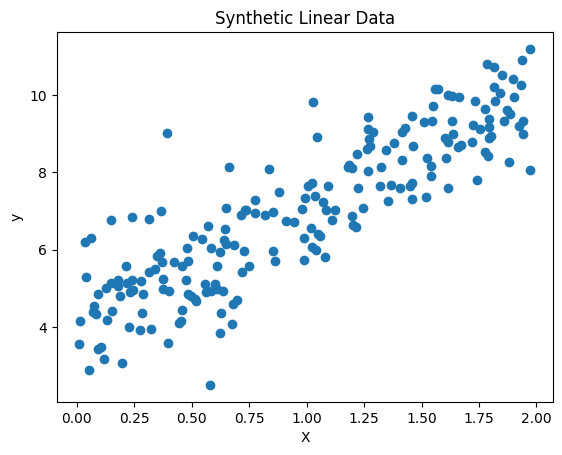

In [7]:
X = 2 * np.random.rand(200, 1)
y = 4 + 3 * X + np.random.randn(200, 1)

plt.scatter(X, y)
plt.title("Synthetic Linear Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# Understanding OLS (Ordinary Least Squares)

OLS minimizes:

${\sum (y - \hat{y})^2}$

Why squared?
	•	Prevents negative cancellation
	•	Penalizes large errors more
	•	Smooth & differentiable

Closed-form solution:

${\theta = (X^T X)^{-1} X^T y}$

This comes from setting derivative to zero.

# Train Model Using sklearn

Expected:
- Intercept ≈ 4
- Coefficient ≈ 3

Intercept: [4.10520115]
Coefficient: [[2.96096447]]


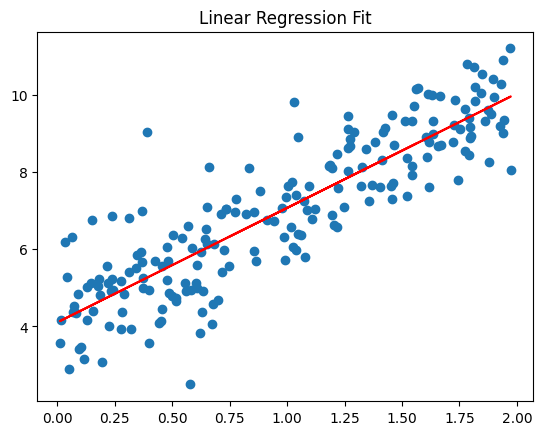

In [8]:
model = LinearRegression()
model.fit(X, y)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

# Visualize Model Fit
y_pred = model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred, color="red")
plt.title("Linear Regression Fit")
plt.show()

# Evaluate Model

Mean Squared Error (MSE)

${MSE = \frac{1}{n} \sum (y - \hat{y})^2}$

Interpretation:
- Lower is better
- Sensitive to outliers
- Same unit as squared target

R² Score

${R^2 = 1 - \frac{SS_{res}}{SS_{tot}}}$

Interpretation:
- 1 → Perfect fit
- 0 → Same as predicting mean
- < 0 → Worse than baselin

In [9]:
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

r2 = r2_score(y, y_pred)
print("R²:", r2)

MSE: 0.9338262007909794
R²: 0.7646745401359959


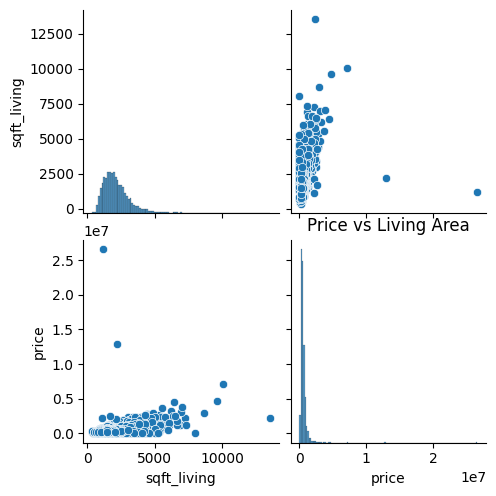

Model prediction for 3300 sqft area : [844389.67489186]
m (coefficent) : [251.95013106]
b (intercept) : 12954.242396381916
Manual prediction for 3300 sqft area : [844389.67489186]


In [11]:
# Example i.e with actual data

pd.options.display.float_format = '{:.2f}'.format

# We using house price dataset, as it is the one of the simplest for linear regression
# We can other below datasets too for linear regression
# `Student Performance`, `Auto MPG`, `Wine Quality`, `CDC Data: Nutrition, Physical Activity, Obesity`
df = pd.read_csv('../../../datasets/house-price.csv',)

# Remove objects
num = []
cat = []
for cols in df.columns:
    if df[cols].dtype == 'O':
        cat.append(cols)
    else:
        num.append(cols)

# 1. Linear Regression Single Variable example i.e getting price based on area (price = m*area + b)
single_variable_df = df[['sqft_living','price']]

sns.pairplot(single_variable_df)
# plt.show()

%matplotlib inline
# plt.figure(figsize=(8,5))
# plt.scatter(single_variable_df.sqft_living, single_variable_df.price, color="red", marker="+")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.title("Price vs Living Area")
plt.show()

# Fit the model
linear_model = LinearRegression()
linear_model.fit(single_variable_df[['sqft_living']], single_variable_df.price)

# Predict using a DataFrame with same column name
# as (price = m*area + b) and we only provided area i.e 3300
single_variable_prediction = linear_model.predict(
    pd.DataFrame([[3300]], columns=['sqft_living'])
    )

print(f"Model prediction for 3300 sqft area : {single_variable_prediction}")

# model calculated m and b on it's own
print(f'm (coefficent) : {linear_model.coef_}')
print(f'b (intercept) : {linear_model.intercept_}')

# now we can try manually with formula
manual_single_variable_prediction = linear_model.coef_*3300 + linear_model.intercept_
print(f"Manual prediction for 3300 sqft area : {single_variable_prediction}")